In [1]:
# =========================================
# 06B_grouped_extreme_classification.ipynb
# DOI-grouped extreme-class stability classification
# =========================================
import os
import json
import time
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

pd.set_option("display.max_columns", 300)
pd.set_option("display.max_rows", 200)

WORK_DIR = r"C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026"

X_FILE = os.path.join(WORK_DIR, "interim", "X_features.parquet")
Y_FILE = os.path.join(WORK_DIR, "interim", "y_target.parquet")
GROUP_FILE = os.path.join(WORK_DIR, "interim", "groups.parquet")
ROWID_FILE = os.path.join(WORK_DIR, "interim", "row_ids.parquet")

REPORT_DIR = os.path.join(WORK_DIR, "reports")
META_DIR = os.path.join(WORK_DIR, "metadata")
ARTIFACT_DIR = os.path.join(WORK_DIR, "artifacts", "06B_extreme_classification")

for p in [REPORT_DIR, META_DIR, ARTIFACT_DIR]:
    os.makedirs(p, exist_ok=True)

In [2]:
X = pd.read_parquet(X_FILE)
y = pd.read_parquet(Y_FILE)["T80_log1p"].copy()
groups = pd.read_parquet(GROUP_FILE)["Ref_DOI_number"].copy()
row_ids = pd.read_parquet(ROWID_FILE)["raw_row_id"].copy()

assert len(X) == len(y) == len(groups) == len(row_ids)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("unique DOI:", groups.nunique())

X shape: (1835, 77)
y shape: (1835,)
unique DOI: 964


In [3]:
quantile_settings = [
    ("30_70", 0.30, 0.70),
    ("25_75", 0.25, 0.75),
]

all_gss_scores = []
all_gss_summaries = []
all_gkf_scores = []
all_gkf_summaries = []

prepared_datasets = {}

for setting_name, LOW_Q, HIGH_Q in quantile_settings:
    q_low = y.quantile(LOW_Q)
    q_high = y.quantile(HIGH_Q)

    keep_mask = (y <= q_low) | (y >= q_high)

    X_cls = X.loc[keep_mask].copy()
    y_cls = y.loc[keep_mask].copy()
    groups_cls = groups.loc[keep_mask].copy()
    row_ids_cls = row_ids.loc[keep_mask].copy()

    # 0 = low stability, 1 = high stability
    y_bin = (y_cls >= q_high).astype(int)

    prepared_datasets[setting_name] = {
        "LOW_Q": LOW_Q,
        "HIGH_Q": HIGH_Q,
        "q_low": q_low,
        "q_high": q_high,
        "X_cls": X_cls,
        "y_cls": y_cls,
        "groups_cls": groups_cls,
        "row_ids_cls": row_ids_cls,
        "y_bin": y_bin,
    }

    print("\n===================================")
    print("Setting:", setting_name)
    print("q_low:", q_low)
    print("q_high:", q_high)
    print("Classification rows kept:", len(X_cls))
    print("Low class count:", int((y_bin == 0).sum()))
    print("High class count:", int((y_bin == 1).sum()))
    print("Unique DOI kept:", groups_cls.nunique())


Setting: 30_70
q_low: 3.9318256327243257
q_high: 5.8888779583328805
Classification rows kept: 1120
Low class count: 557
High class count: 563
Unique DOI kept: 683

Setting: 25_75
q_low: 3.6109179126442243
q_high: 6.148322171857281
Classification rows kept: 921
Low class count: 462
High class count: 459
Unique DOI kept: 564


In [4]:
def evaluate_binary(y_true, y_prob, y_pred):
    return {
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "balanced_acc": balanced_accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "n_test": len(y_true),
    }

def summarize_scores(df_scores, split_name, model_name):
    out = {"split": split_name, "model": model_name, "n_runs": len(df_scores)}
    for m in ["roc_auc", "pr_auc", "balanced_acc", "f1", "n_test"]:
        out[f"{m}_mean"] = df_scores[m].mean()
        out[f"{m}_std"] = df_scores[m].std(ddof=1) if len(df_scores) > 1 else 0.0
    return out

In [5]:
models = {
    "logistic": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=SEED
        ))
    ]),
    "random_forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=500,
            max_depth=None,
            min_samples_split=4,
            min_samples_leaf=2,
            class_weight="balanced",
            n_jobs=-1,
            random_state=SEED
        ))
    ]),
    "hist_gb": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", HistGradientBoostingClassifier(
            learning_rate=0.05,
            max_depth=6,
            max_iter=400,
            min_samples_leaf=10,
            random_state=SEED
        ))
    ]),
}

print("Models:", list(models.keys()))

Models: ['logistic', 'random_forest', 'hist_gb']


In [6]:
def run_group_shuffle_classification(X, y_bin, groups, models, n_repeats=30, test_size=0.2, seed=42):
    all_scores = []
    fitted_examples = {}

    splitter = GroupShuffleSplit(
        n_splits=n_repeats,
        test_size=test_size,
        random_state=seed
    )

    for rep, (train_idx, test_idx) in enumerate(splitter.split(X, y_bin, groups), start=1):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y_bin.iloc[train_idx]
        y_test = y_bin.iloc[test_idx]
        g_test = groups.iloc[test_idx]

        for model_name, model in models.items():
            t0 = time.time()
            model.fit(X_train, y_train)

            y_prob = model.predict_proba(X_test)[:, 1]
            y_pred = (y_prob >= 0.5).astype(int)

            metrics = evaluate_binary(y_test, y_prob, y_pred)
            metrics["split"] = "group_shuffle_split"
            metrics["model"] = model_name
            metrics["repeat"] = rep
            metrics["fit_seconds"] = time.time() - t0
            metrics["n_test_groups"] = g_test.nunique()
            all_scores.append(metrics)

            fitted_examples[model_name] = {
                "y_true": np.array(y_test),
                "y_prob": np.array(y_prob),
                "y_pred": np.array(y_pred)
            }

    return pd.DataFrame(all_scores), fitted_examples

gss_example_store = {}

for setting_name, ds in prepared_datasets.items():
    print("\n==============================")
    print("GroupShuffleSplit:", setting_name)
    print("==============================")

    gss_scores, gss_examples = run_group_shuffle_classification(
        X=ds["X_cls"],
        y_bin=ds["y_bin"],
        groups=ds["groups_cls"],
        models=models,
        n_repeats=30,
        test_size=0.2,
        seed=SEED
    )

    gss_scores["setting"] = setting_name
    all_gss_scores.append(gss_scores)

    gss_summary_rows = []
    for model_name in gss_scores["model"].unique():
        dfm = gss_scores[gss_scores["model"] == model_name].copy()
        row = summarize_scores(dfm, "group_shuffle_split", model_name)
        row["setting"] = setting_name
        row["rows_after_filtering"] = int(len(ds["X_cls"]))
        row["n_unique_doi"] = int(ds["groups_cls"].nunique())
        gss_summary_rows.append(row)

    gss_summary = pd.DataFrame(gss_summary_rows).sort_values("roc_auc_mean", ascending=False)
    all_gss_summaries.append(gss_summary)

    gss_example_store[setting_name] = gss_examples

    print(gss_summary)


GroupShuffleSplit: 30_70
                 split          model  n_runs  roc_auc_mean  roc_auc_std  \
1  group_shuffle_split  random_forest      30      0.747551     0.038018   
0  group_shuffle_split       logistic      30      0.724075     0.042451   
2  group_shuffle_split        hist_gb      30      0.690855     0.042032   

   pr_auc_mean  pr_auc_std  balanced_acc_mean  balanced_acc_std   f1_mean  \
1     0.721615    0.049244           0.689193          0.033735  0.697359   
0     0.686852    0.058081           0.681141          0.032338  0.692410   
2     0.665896    0.062988           0.653422          0.034706  0.667969   

     f1_std  n_test_mean  n_test_std setting  rows_after_filtering  \
1  0.033224   223.933333   13.122587   30_70                  1120   
0  0.030404   223.933333   13.122587   30_70                  1120   
2  0.036803   223.933333   13.122587   30_70                  1120   

   n_unique_doi  
1           683  
0           683  
2           683  

GroupS

In [7]:
gss_scores_all = pd.concat(all_gss_scores, axis=0, ignore_index=True)
gss_summary_all = pd.concat(all_gss_summaries, axis=0, ignore_index=True)

print("Combined GroupShuffleSplit summary:")
print(
    gss_summary_all.sort_values(
        ["setting", "roc_auc_mean"],
        ascending=[True, False]
    ).reset_index(drop=True)
)

Combined GroupShuffleSplit summary:
                 split          model  n_runs  roc_auc_mean  roc_auc_std  \
0  group_shuffle_split  random_forest      30      0.752105     0.039815   
1  group_shuffle_split       logistic      30      0.741168     0.044489   
2  group_shuffle_split        hist_gb      30      0.717180     0.047211   
3  group_shuffle_split  random_forest      30      0.747551     0.038018   
4  group_shuffle_split       logistic      30      0.724075     0.042451   
5  group_shuffle_split        hist_gb      30      0.690855     0.042032   

   pr_auc_mean  pr_auc_std  balanced_acc_mean  balanced_acc_std   f1_mean  \
0     0.731463    0.054386           0.687382          0.041519  0.692039   
1     0.701191    0.078940           0.689904          0.042018  0.702225   
2     0.683748    0.072488           0.668318          0.041619  0.680301   
3     0.721615    0.049244           0.689193          0.033735  0.697359   
4     0.686852    0.058081           0.681141 

In [8]:
def run_group_kfold_classification(X, y_bin, groups, models, n_splits=5):
    all_scores = []
    fitted_examples = {}

    splitter = GroupKFold(n_splits=n_splits)

    for fold, (train_idx, test_idx) in enumerate(splitter.split(X, y_bin, groups), start=1):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y_bin.iloc[train_idx]
        y_test = y_bin.iloc[test_idx]
        g_test = groups.iloc[test_idx]

        for model_name, model in models.items():
            t0 = time.time()
            model.fit(X_train, y_train)

            y_prob = model.predict_proba(X_test)[:, 1]
            y_pred = (y_prob >= 0.5).astype(int)

            metrics = evaluate_binary(y_test, y_prob, y_pred)
            metrics["split"] = "group_kfold"
            metrics["model"] = model_name
            metrics["fold"] = fold
            metrics["fit_seconds"] = time.time() - t0
            metrics["n_test_groups"] = g_test.nunique()

            all_scores.append(metrics)

            fitted_examples[model_name] = {
                "y_true": np.array(y_test),
                "y_prob": np.array(y_prob),
                "y_pred": np.array(y_pred)
            }

    return pd.DataFrame(all_scores), fitted_examples

In [9]:
gkf_example_store = {}

for setting_name, ds in prepared_datasets.items():
    print("\n==============================")
    print("GroupKFold:", setting_name)
    print("==============================")

    gkf_scores, gkf_examples = run_group_kfold_classification(
        X=ds["X_cls"],
        y_bin=ds["y_bin"],
        groups=ds["groups_cls"],
        models=models,
        n_splits=5
    )

    gkf_scores["setting"] = setting_name
    all_gkf_scores.append(gkf_scores)

    gkf_summary_rows = []
    for model_name in gkf_scores["model"].unique():
        dfm = gkf_scores[gkf_scores["model"] == model_name].copy()
        row = summarize_scores(dfm, "group_kfold", model_name)
        row["setting"] = setting_name
        row["rows_after_filtering"] = int(len(ds["X_cls"]))
        row["n_unique_doi"] = int(ds["groups_cls"].nunique())
        gkf_summary_rows.append(row)

    gkf_summary = pd.DataFrame(gkf_summary_rows).sort_values("roc_auc_mean", ascending=False)
    all_gkf_summaries.append(gkf_summary)

    gkf_example_store[setting_name] = gkf_examples

    print(gkf_summary)


GroupKFold: 30_70
         split          model  n_runs  roc_auc_mean  roc_auc_std  pr_auc_mean  \
1  group_kfold  random_forest       5      0.747501     0.052379     0.717537   
0  group_kfold       logistic       5      0.722132     0.038055     0.689442   
2  group_kfold        hist_gb       5      0.695377     0.046490     0.674088   

   pr_auc_std  balanced_acc_mean  balanced_acc_std   f1_mean    f1_std  \
1    0.093156           0.687162          0.046924  0.702230  0.054933   
0    0.081584           0.664737          0.035097  0.681762  0.045223   
2    0.081532           0.643909          0.013624  0.667865  0.035854   

   n_test_mean  n_test_std setting  rows_after_filtering  n_unique_doi  
1        224.0         0.0   30_70                  1120           683  
0        224.0         0.0   30_70                  1120           683  
2        224.0         0.0   30_70                  1120           683  

GroupKFold: 25_75
         split          model  n_runs  roc_auc_m

In [10]:
gkf_scores_all = pd.concat(all_gkf_scores, axis=0, ignore_index=True)
gkf_summary_all = pd.concat(all_gkf_summaries, axis=0, ignore_index=True)

print("Combined GroupKFold summary:")
print(
    gkf_summary_all.sort_values(
        ["setting", "roc_auc_mean"],
        ascending=[True, False]
    ).reset_index(drop=True)
)

Combined GroupKFold summary:
         split          model  n_runs  roc_auc_mean  roc_auc_std  pr_auc_mean  \
0  group_kfold  random_forest       5      0.763130     0.061767     0.750319   
1  group_kfold       logistic       5      0.740872     0.045237     0.704205   
2  group_kfold        hist_gb       5      0.728493     0.031487     0.688199   
3  group_kfold  random_forest       5      0.747501     0.052379     0.717537   
4  group_kfold       logistic       5      0.722132     0.038055     0.689442   
5  group_kfold        hist_gb       5      0.695377     0.046490     0.674088   

   pr_auc_std  balanced_acc_mean  balanced_acc_std   f1_mean    f1_std  \
0    0.039394           0.688413          0.058587  0.699743  0.033991   
1    0.033943           0.695278          0.053428  0.715562  0.029172   
2    0.051674           0.674729          0.033794  0.690086  0.018131   
3    0.093156           0.687162          0.046924  0.702230  0.054933   
4    0.081584           0.664737 

In [11]:
# ============================================================
# REVIEWER 2 — COMMENT 4
# TRAINING-ONLY QUANTILE THRESHOLD SENSITIVITY
#
# DOI groups are split FIRST.
# Q25/Q75 or Q30/Q70 thresholds are then calculated using
# TRAINING outcomes only and applied unchanged to test data.
# ============================================================

import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score
)

quantile_settings_leakage = [
    ("25_75", 0.25, 0.75),
    ("30_70", 0.30, 0.70)
]

rf_model = models["random_forest"]

leakage_safe_rows = []


# ============================================================
# FUNCTION
# ============================================================

def evaluate_training_only_thresholds(
    split_name,
    split_iterator,
    setting_name,
    low_q,
    high_q
):

    for split_no, (train_idx, test_idx) in enumerate(
        split_iterator,
        start=1
    ):

        # ------------------------------------------
        # Split full dataset FIRST
        # ------------------------------------------

        X_train_full = X.iloc[train_idx].copy()
        X_test_full = X.iloc[test_idx].copy()

        y_train_full = y.iloc[train_idx].copy()
        y_test_full = y.iloc[test_idx].copy()

        g_train_full = groups.iloc[train_idx].copy()
        g_test_full = groups.iloc[test_idx].copy()

        # ------------------------------------------
        # Thresholds calculated from TRAINING y only
        # ------------------------------------------

        q_low_train = y_train_full.quantile(low_q)
        q_high_train = y_train_full.quantile(high_q)

        # ------------------------------------------
        # Apply same training-derived thresholds
        # to train and test sets
        # ------------------------------------------

        train_extreme = (
            (y_train_full <= q_low_train)
            |
            (y_train_full >= q_high_train)
        )

        test_extreme = (
            (y_test_full <= q_low_train)
            |
            (y_test_full >= q_high_train)
        )

        X_train = X_train_full.loc[train_extreme].copy()
        y_train_cont = y_train_full.loc[train_extreme].copy()

        X_test = X_test_full.loc[test_extreme].copy()
        y_test_cont = y_test_full.loc[test_extreme].copy()

        g_test = g_test_full.loc[test_extreme].copy()

        # Binary labels use TRAINING-derived q_high
        y_train_bin = (
            y_train_cont >= q_high_train
        ).astype(int)

        y_test_bin = (
            y_test_cont >= q_high_train
        ).astype(int)

        # Skip unusable split
        if (
            y_train_bin.nunique() < 2
            or
            y_test_bin.nunique() < 2
        ):
            continue

        # ------------------------------------------
        # Fit RF
        # ------------------------------------------

        model = clone(rf_model)

        model.fit(
            X_train,
            y_train_bin
        )

        y_prob = model.predict_proba(
            X_test
        )[:, 1]

        y_pred = (
            y_prob >= 0.5
        ).astype(int)

        leakage_safe_rows.append({

            "setting": setting_name,
            "validation": split_name,
            "split_no": split_no,

            "q_low_train":
                q_low_train,

            "q_high_train":
                q_high_train,

            "train_extreme_devices":
                len(X_train),

            "test_extreme_devices":
                len(X_test),

            "test_DOI":
                g_test.nunique(),

            "roc_auc":
                roc_auc_score(
                    y_test_bin,
                    y_prob
                ),

            "pr_auc":
                average_precision_score(
                    y_test_bin,
                    y_prob
                ),

            "balanced_accuracy":
                balanced_accuracy_score(
                    y_test_bin,
                    y_pred
                ),

            "f1":
                f1_score(
                    y_test_bin,
                    y_pred
                )
        })


# ============================================================
# 30-repeat GroupShuffleSplit
# ============================================================

for setting_name, low_q, high_q in quantile_settings_leakage:

    gss = GroupShuffleSplit(
        n_splits=30,
        test_size=0.20,
        random_state=SEED
    )

    evaluate_training_only_thresholds(
        "GroupShuffleSplit",
        gss.split(
            X,
            y,
            groups=groups
        ),
        setting_name,
        low_q,
        high_q
    )


# ============================================================
# 5-fold GroupKFold
# ============================================================

for setting_name, low_q, high_q in quantile_settings_leakage:

    gkf = GroupKFold(
        n_splits=5
    )

    evaluate_training_only_thresholds(
        "GroupKFold",
        gkf.split(
            X,
            y,
            groups=groups
        ),
        setting_name,
        low_q,
        high_q
    )


# ============================================================
# SUMMARY
# ============================================================

leakage_safe_scores = pd.DataFrame(
    leakage_safe_rows
)

leakage_safe_summary = (
    leakage_safe_scores
    .groupby(
        [
            "setting",
            "validation"
        ]
    )
    .agg(

        n_splits=(
            "roc_auc",
            "count"
        ),

        roc_auc_mean=(
            "roc_auc",
            "mean"
        ),

        roc_auc_std=(
            "roc_auc",
            "std"
        ),

        pr_auc_mean=(
            "pr_auc",
            "mean"
        ),

        pr_auc_std=(
            "pr_auc",
            "std"
        ),

        balanced_accuracy_mean=(
            "balanced_accuracy",
            "mean"
        ),

        balanced_accuracy_std=(
            "balanced_accuracy",
            "std"
        ),

        f1_mean=(
            "f1",
            "mean"
        ),

        f1_std=(
            "f1",
            "std"
        ),

        test_devices_mean=(
            "test_extreme_devices",
            "mean"
        ),

        test_DOI_mean=(
            "test_DOI",
            "mean"
        )
    )
    .reset_index()
)

print(
    "========== TRAINING-ONLY THRESHOLD SENSITIVITY =========="
)

display(
    leakage_safe_summary
)

# Save
leakage_safe_scores.to_csv(
    os.path.join(
        REPORT_DIR,
        "06B_training_only_threshold_scores.csv"
    ),
    index=False
)

leakage_safe_summary.to_csv(
    os.path.join(
        REPORT_DIR,
        "06B_training_only_threshold_summary.csv"
    ),
    index=False
)

print(
    "\nSaved training-only threshold sensitivity analysis."
)

========== TRAINING-ONLY THRESHOLD SENSITIVITY ==========


,setting,validation,n_splits,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,test_devices_mean,test_DOI_mean
0,25_75,GroupKFold,5,0.772250,0.047802,0.763129,0.029734,0.713068,0.017540,0.716866,0.024798,187.400000,114.400000
1,25_75,GroupShuffleSplit,30,0.758184,0.033495,0.737564,0.053316,0.699505,0.038066,0.704666,0.044241,184.466667,114.000000
2,30_70,GroupKFold,5,0.752439,0.049806,0.726953,0.053257,0.694311,0.024699,0.704324,0.044364,222.600000,135.600000
3,30_70,GroupShuffleSplit,30,0.742355,0.028654,0.717221,0.054969,0.688050,0.030397,0.693831,0.036702,221.100000,134.866667



Saved training-only threshold sensitivity analysis.


In [12]:
# ============================================================
# REVIEWER 2 — COMMENT 5
# CHRONOLOGICAL EXTREME-CLASS CLASSIFICATION
#
# Train: publication year <= 2019
# Test : publication year >= 2020
#
# IMPORTANT:
# Quantile thresholds are calculated from TRAINING outcomes
# only and then applied unchanged to the chronological test set.
# ============================================================

import os
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score
)


# ============================================================
# 1. LOAD FINAL LABEL METADATA
# ============================================================

LABEL_FILE = os.path.join(
    WORK_DIR,
    "interim",
    "t80_labels.parquet"
)

label_meta = pd.read_parquet(
    LABEL_FILE
)[[
    "raw_row_id",
    "Ref_DOI_number",
    "publication_year"
]].copy()

label_meta["publication_year"] = pd.to_numeric(
    label_meta["publication_year"],
    errors="coerce"
)


# ============================================================
# 2. ALIGN PUBLICATION YEAR WITH X, y, groups
# ============================================================

analysis_meta = pd.DataFrame({
    "raw_row_id": row_ids.to_numpy(),
    "group_from_model": groups.to_numpy()
})

analysis_meta = analysis_meta.merge(
    label_meta,
    on="raw_row_id",
    how="left",
    validate="one_to_one"
)

assert len(analysis_meta) == len(X)

if analysis_meta["publication_year"].isna().any():
    raise ValueError(
        "Missing publication year after metadata merge."
    )

print(
    "Aligned rows:",
    len(analysis_meta)
)

print(
    "Unique DOI:",
    analysis_meta["Ref_DOI_number"].nunique()
)


# ============================================================
# 3. DEFINE CHRONOLOGICAL SPLIT
# ============================================================

train_full_mask = (
    analysis_meta["publication_year"] <= 2019
).to_numpy()

test_full_mask = (
    analysis_meta["publication_year"] >= 2020
).to_numpy()

train_idx_full = np.where(
    train_full_mask
)[0]

test_idx_full = np.where(
    test_full_mask
)[0]

train_doi = set(
    groups.iloc[
        train_idx_full
    ].astype(str)
)

test_doi = set(
    groups.iloc[
        test_idx_full
    ].astype(str)
)

doi_overlap = (
    train_doi
    &
    test_doi
)

print("\n========== CHRONOLOGICAL SPLIT ==========")

print(
    "Training years <= 2019"
)

print(
    "Test years >= 2020"
)

print(
    "Train devices:",
    len(train_idx_full)
)

print(
    "Test devices:",
    len(test_idx_full)
)

print(
    "Train DOI:",
    len(train_doi)
)

print(
    "Test DOI:",
    len(test_doi)
)

print(
    "DOI overlap:",
    len(doi_overlap)
)

assert len(doi_overlap) == 0


# ============================================================
# 4. RUN CHRONOLOGICAL CLASSIFICATION
#
# Thresholds are derived ONLY from training y.
# ============================================================

chrono_settings = [
    ("25_75", 0.25, 0.75),
    ("30_70", 0.30, 0.70)
]

chrono_rows = []

for setting_name, low_q, high_q in chrono_settings:

    print(
        "\n========================================"
    )

    print(
        "Chronological setting:",
        setting_name
    )

    print(
        "========================================"
    )

    # --------------------------------------------------------
    # Full chronological train/test data
    # --------------------------------------------------------

    X_train_full = X.iloc[
        train_idx_full
    ].copy()

    X_test_full = X.iloc[
        test_idx_full
    ].copy()

    y_train_full = y.iloc[
        train_idx_full
    ].copy()

    y_test_full = y.iloc[
        test_idx_full
    ].copy()

    groups_train_full = groups.iloc[
        train_idx_full
    ].copy()

    groups_test_full = groups.iloc[
        test_idx_full
    ].copy()


    # --------------------------------------------------------
    # Calculate thresholds from TRAINING data only
    # --------------------------------------------------------

    q_low_train = y_train_full.quantile(
        low_q
    )

    q_high_train = y_train_full.quantile(
        high_q
    )

    print(
        "Training-derived lower threshold:",
        q_low_train
    )

    print(
        "Training-derived upper threshold:",
        q_high_train
    )


    # --------------------------------------------------------
    # Identify extreme devices using training-derived cutoffs
    # --------------------------------------------------------

    train_extreme_mask = (
        (y_train_full <= q_low_train)
        |
        (y_train_full >= q_high_train)
    )

    test_extreme_mask = (
        (y_test_full <= q_low_train)
        |
        (y_test_full >= q_high_train)
    )


    # --------------------------------------------------------
    # Filter train and test
    # --------------------------------------------------------

    X_train = X_train_full.loc[
        train_extreme_mask
    ].copy()

    y_train_cont = y_train_full.loc[
        train_extreme_mask
    ].copy()

    g_train = groups_train_full.loc[
        train_extreme_mask
    ].copy()


    X_test = X_test_full.loc[
        test_extreme_mask
    ].copy()

    y_test_cont = y_test_full.loc[
        test_extreme_mask
    ].copy()

    g_test = groups_test_full.loc[
        test_extreme_mask
    ].copy()


    # --------------------------------------------------------
    # Binary labels
    #
    # Same TRAINING-derived upper threshold used in test data
    # --------------------------------------------------------

    y_train_bin = (
        y_train_cont >= q_high_train
    ).astype(int)

    y_test_bin = (
        y_test_cont >= q_high_train
    ).astype(int)


    print(
        "\nExtreme train devices:",
        len(X_train)
    )

    print(
        "Extreme train DOI:",
        g_train.nunique()
    )

    print(
        "Train class counts:"
    )

    print(
        y_train_bin.value_counts().sort_index()
    )


    print(
        "\nExtreme test devices:",
        len(X_test)
    )

    print(
        "Extreme test DOI:",
        g_test.nunique()
    )

    print(
        "Test class counts:"
    )

    print(
        y_test_bin.value_counts().sort_index()
    )


    # --------------------------------------------------------
    # Safety check
    # --------------------------------------------------------

    if y_test_bin.nunique() < 2:

        print(
            "WARNING: Test set contains only one class."
        )

        continue


    # --------------------------------------------------------
    # Evaluate all three classifier families
    # --------------------------------------------------------

    for model_name, model_template in models.items():

        model = clone(
            model_template
        )

        model.fit(
            X_train,
            y_train_bin
        )

        y_prob = model.predict_proba(
            X_test
        )[:, 1]

        y_pred = (
            y_prob >= 0.5
        ).astype(int)


        roc_auc = roc_auc_score(
            y_test_bin,
            y_prob
        )

        pr_auc = average_precision_score(
            y_test_bin,
            y_prob
        )

        bal_acc = balanced_accuracy_score(
            y_test_bin,
            y_pred
        )

        f1 = f1_score(
            y_test_bin,
            y_pred
        )


        chrono_rows.append({

            "setting":
                setting_name,

            "model":
                model_name,

            "train_years":
                "<=2019",

            "test_years":
                ">=2020",

            "q_low_train":
                q_low_train,

            "q_high_train":
                q_high_train,

            "n_train_extreme":
                len(X_train),

            "n_train_DOI":
                g_train.nunique(),

            "n_test_extreme":
                len(X_test),

            "n_test_DOI":
                g_test.nunique(),

            "test_low":
                int(
                    (y_test_bin == 0).sum()
                ),

            "test_high":
                int(
                    (y_test_bin == 1).sum()
                ),

            "roc_auc":
                roc_auc,

            "pr_auc":
                pr_auc,

            "balanced_accuracy":
                bal_acc,

            "f1":
                f1
        })


# ============================================================
# 5. SUMMARY TABLE
# ============================================================

chrono_cls_results = pd.DataFrame(
    chrono_rows
)

chrono_cls_results = (
    chrono_cls_results
    .sort_values(
        [
            "setting",
            "roc_auc"
        ],
        ascending=[
            True,
            False
        ]
    )
    .reset_index(
        drop=True
    )
)

print(
    "\n========== CHRONOLOGICAL CLASSIFICATION RESULTS =========="
)

display(
    chrono_cls_results
)


# ============================================================
# 6. BEST MODEL PER THRESHOLD SETTING
# ============================================================

best_chrono = (
    chrono_cls_results
    .sort_values(
        [
            "setting",
            "roc_auc"
        ],
        ascending=[
            True,
            False
        ]
    )
    .groupby(
        "setting",
        as_index=False
    )
    .first()
)

print(
    "\n========== BEST CHRONOLOGICAL MODEL PER SETTING =========="
)

display(
    best_chrono
)


# ============================================================
# 7. SAVE RESULTS
# ============================================================

chrono_cls_results.to_csv(
    os.path.join(
        REPORT_DIR,
        "06B_chronological_extreme_classification_all_models.csv"
    ),
    index=False
)

best_chrono.to_csv(
    os.path.join(
        REPORT_DIR,
        "06B_chronological_extreme_classification_best_models.csv"
    ),
    index=False
)

print(
    "\nSaved chronological classification results."
)

Aligned rows: 1835
Unique DOI: 964

========== CHRONOLOGICAL SPLIT ==========
Training years <= 2019
Test years >= 2020
Train devices: 1741
Test devices: 94
Train DOI: 917
Test DOI: 47
DOI overlap: 0

Chronological setting: 25_75
Training-derived lower threshold: 3.6109179126442243
Training-derived upper threshold: 6.104793232414985

Extreme train devices: 878
Extreme train DOI: 537
Train class counts:
T80_log1p
0    442
1    436
Name: count, dtype: int64

Extreme test devices: 52
Extreme test DOI: 33
Test class counts:
T80_log1p
0    20
1    32
Name: count, dtype: int64

Chronological setting: 30_70
Training-derived lower threshold: 3.9318256327243257
Training-derived upper threshold: 5.8888779583328805

Extreme train devices: 1062
Extreme train DOI: 647
Train class counts:
T80_log1p
0    537
1    525
Name: count, dtype: int64

Extreme test devices: 58
Extreme test DOI: 36
Test class counts:
T80_log1p
0    20
1    38
Name: count, dtype: int64

========== CHRONOLOGICAL CLASSIFICATION R

,setting,model,train_years,test_years,q_low_train,q_high_train,n_train_extreme,n_train_DOI,n_test_extreme,n_test_DOI,test_low,test_high,roc_auc,pr_auc,balanced_accuracy,f1
0,25_75,logistic,<=2019,>=2020,3.610918,6.104793,878,537,52,33,20,32,0.659375,0.800781,0.621875,0.488889
1,25_75,random_forest,<=2019,>=2020,3.610918,6.104793,878,537,52,33,20,32,0.642188,0.779518,0.659375,0.600000
2,25_75,hist_gb,<=2019,>=2020,3.610918,6.104793,878,537,52,33,20,32,0.460938,0.625392,0.475000,0.347826
3,30_70,logistic,<=2019,>=2020,3.931826,5.888878,1062,647,58,36,20,38,0.707895,0.843132,0.634211,0.518519
4,30_70,random_forest,<=2019,>=2020,3.931826,5.888878,1062,647,58,36,20,38,0.697368,0.819141,0.713158,0.666667
5,30_70,hist_gb,<=2019,>=2020,3.931826,5.888878,1062,647,58,36,20,38,0.430263,0.620066,0.432895,0.406780



========== BEST CHRONOLOGICAL MODEL PER SETTING ==========


,setting,model,train_years,test_years,q_low_train,q_high_train,n_train_extreme,n_train_DOI,n_test_extreme,n_test_DOI,test_low,test_high,roc_auc,pr_auc,balanced_accuracy,f1
0,25_75,logistic,<=2019,>=2020,3.610918,6.104793,878,537,52,33,20,32,0.659375,0.800781,0.621875,0.488889
1,30_70,logistic,<=2019,>=2020,3.931826,5.888878,1062,647,58,36,20,38,0.707895,0.843132,0.634211,0.518519



Saved chronological classification results.


Chronological train devices: 1741
Chronological test devices: 94
25–75 chronological: n = 52 ROC-AUC = 0.659 PR-AUC = 0.801
30–70 chronological: n = 58 ROC-AUC = 0.708 PR-AUC = 0.843
Saving Figure 4 to:
C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\final_figures\Figure4_FINAL_extreme_classification.png


OSError: [Errno 22] Invalid argument: 'C:\\Users\\khanm\\OneDrive\\Desktop\\3rd model 18-03-2026\\final_figures\\Figure4_FINAL_extreme_classification.png'

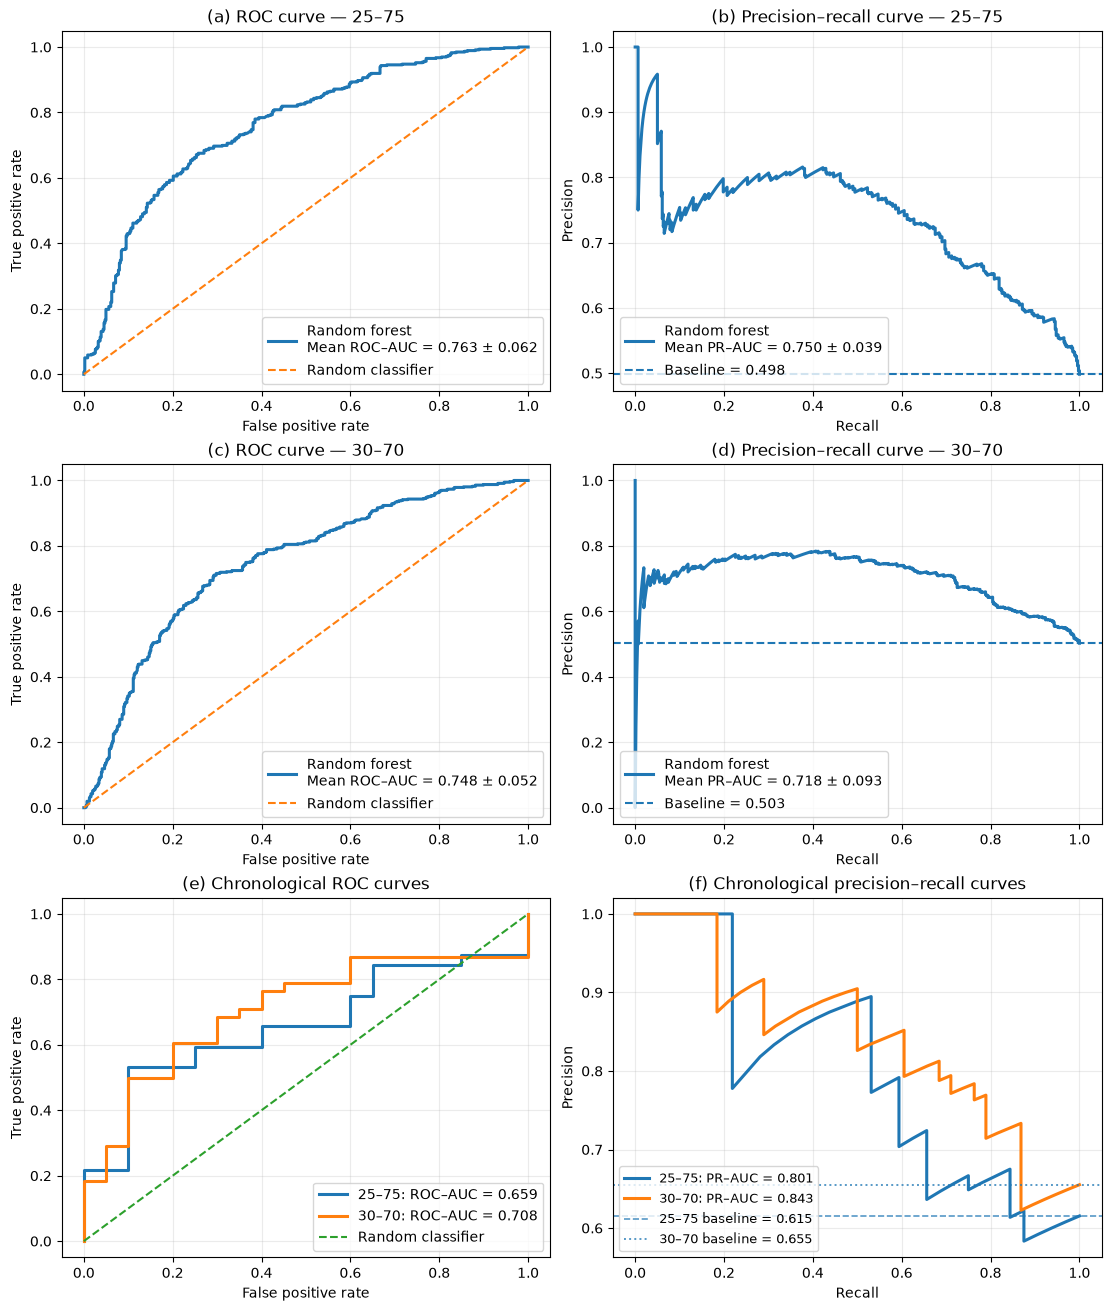

In [13]:
# ============================================================
# FINAL FIGURE 4 + FIGURE S5
# Uses final 1835-device dataset
# 5-fold DOI-grouped OOF predictions
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    confusion_matrix
)


# ------------------------------------------------------------
# Collect 5-fold OOF RF predictions
# ------------------------------------------------------------

def get_final_oof(setting_name):

    ds = prepared_datasets[setting_name]

    Xc = ds["X_cls"]
    yc = ds["y_bin"]
    gc = ds["groups_cls"]

    splitter = GroupKFold(n_splits=5)

    oof_prob = np.full(len(Xc), np.nan)

    for train_idx, test_idx in splitter.split(Xc, yc, gc):

        model = clone(models["random_forest"])

        model.fit(
            Xc.iloc[train_idx],
            yc.iloc[train_idx]
        )

        oof_prob[test_idx] = model.predict_proba(
            Xc.iloc[test_idx]
        )[:, 1]

    # final mean metrics already calculated in notebook
    summary_row = (
        gkf_summary_all[
            (gkf_summary_all["setting"] == setting_name) &
            (gkf_summary_all["model"] == "random_forest")
        ]
        .iloc[0]
    )

    return {
        "y": yc.to_numpy(),
        "prob": oof_prob,
        "roc_mean": summary_row["roc_auc_mean"],
        "roc_std": summary_row["roc_auc_std"],
        "pr_mean": summary_row["pr_auc_mean"],
        "pr_std": summary_row["pr_auc_std"]
    }


res25 = get_final_oof("25_75")
res30 = get_final_oof("30_70")


# ------------------------------------------------------------
# Curves
# ------------------------------------------------------------

fpr25, tpr25, _ = roc_curve(
    res25["y"],
    res25["prob"]
)

p25, r25, _ = precision_recall_curve(
    res25["y"],
    res25["prob"]
)

fpr30, tpr30, _ = roc_curve(
    res30["y"],
    res30["prob"]
)

p30, r30, _ = precision_recall_curve(
    res30["y"],
    res30["prob"]
)

base25 = np.mean(res25["y"])
base30 = np.mean(res30["y"])


# ============================================================
# FIGURE 4
# ============================================================

fig, axes = plt.subplots(
    3, 2,
    figsize=(11, 13),
    constrained_layout=True
)

# (a)
axes[0,0].plot(fpr25, tpr25, linewidth=2.2,
    label=f"Random forest\nMean ROC–AUC = {res25['roc_mean']:.3f} ± {res25['roc_std']:.3f}")
axes[0,0].plot([0,1], [0,1], "--", linewidth=1.5, label="Random classifier")
axes[0,0].set_xlabel("False positive rate")
axes[0,0].set_ylabel("True positive rate")
axes[0,0].set_title("(a) ROC curve — 25–75")
axes[0,0].legend(loc="lower right")
axes[0,0].grid(alpha=0.25)

# (b)
axes[0,1].plot(r25, p25, linewidth=2.2,
    label=f"Random forest\nMean PR–AUC = {res25['pr_mean']:.3f} ± {res25['pr_std']:.3f}")
axes[0,1].axhline(base25, linestyle="--", linewidth=1.5,
                  label=f"Baseline = {base25:.3f}")
axes[0,1].set_xlabel("Recall")
axes[0,1].set_ylabel("Precision")
axes[0,1].set_title("(b) Precision–recall curve — 25–75")
axes[0,1].legend(loc="lower left")
axes[0,1].grid(alpha=0.25)

# (c)
axes[1,0].plot(fpr30, tpr30, linewidth=2.2,
    label=f"Random forest\nMean ROC–AUC = {res30['roc_mean']:.3f} ± {res30['roc_std']:.3f}")
axes[1,0].plot([0,1], [0,1], "--", linewidth=1.5, label="Random classifier")
axes[1,0].set_xlabel("False positive rate")
axes[1,0].set_ylabel("True positive rate")
axes[1,0].set_title("(c) ROC curve — 30–70")
axes[1,0].legend(loc="lower right")
axes[1,0].grid(alpha=0.25)

# (d)
axes[1,1].plot(r30, p30, linewidth=2.2,
    label=f"Random forest\nMean PR–AUC = {res30['pr_mean']:.3f} ± {res30['pr_std']:.3f}")
axes[1,1].axhline(base30, linestyle="--", linewidth=1.5,
                  label=f"Baseline = {base30:.3f}")
axes[1,1].set_xlabel("Recall")
axes[1,1].set_ylabel("Precision")
axes[1,1].set_title("(d) Precision–recall curve — 30–70")
axes[1,1].legend(loc="lower left")
axes[1,1].grid(alpha=0.25)

# ============================================================
# REPLACEMENT FOR FIGURE 4 PANELS (e) AND (f)
# Chronological classification
#
# Train: publication year <= 2019
# Test : publication year >= 2020
# Thresholds derived from TRAINING data only
# Best chronological model: logistic regression
# ============================================================

from sklearn.base import clone
from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    roc_auc_score,
    average_precision_score
)

# ------------------------------------------------------------
# 1. Ensure chronological metadata are aligned
# ------------------------------------------------------------

LABEL_FILE = os.path.join(
    WORK_DIR,
    "interim",
    "t80_labels.parquet"
)

label_meta_fig4 = pd.read_parquet(
    LABEL_FILE
)[[
    "raw_row_id",
    "publication_year"
]].copy()

label_meta_fig4["publication_year"] = pd.to_numeric(
    label_meta_fig4["publication_year"],
    errors="coerce"
)

meta_fig4 = pd.DataFrame({
    "raw_row_id": row_ids.to_numpy()
})

meta_fig4 = meta_fig4.merge(
    label_meta_fig4,
    on="raw_row_id",
    how="left",
    validate="one_to_one"
)

assert len(meta_fig4) == len(X)

if meta_fig4["publication_year"].isna().any():
    raise ValueError(
        "Missing publication year after alignment."
    )


# ------------------------------------------------------------
# 2. Define chronological train/test indices
# ------------------------------------------------------------

chrono_train_idx = np.where(
    meta_fig4["publication_year"].to_numpy() <= 2019
)[0]

chrono_test_idx = np.where(
    meta_fig4["publication_year"].to_numpy() >= 2020
)[0]

print("Chronological train devices:", len(chrono_train_idx))
print("Chronological test devices:", len(chrono_test_idx))


# ------------------------------------------------------------
# 3. Function to generate chronological probabilities
# ------------------------------------------------------------

def get_chronological_curve_data(low_q, high_q):

    # Full train/test sets
    X_train_full = X.iloc[chrono_train_idx].copy()
    X_test_full = X.iloc[chrono_test_idx].copy()

    y_train_full = y.iloc[chrono_train_idx].copy()
    y_test_full = y.iloc[chrono_test_idx].copy()

    # IMPORTANT:
    # thresholds calculated only from training outcomes
    q_low_train = y_train_full.quantile(low_q)
    q_high_train = y_train_full.quantile(high_q)

    # Select extreme devices
    train_extreme = (
        (y_train_full <= q_low_train)
        |
        (y_train_full >= q_high_train)
    )

    test_extreme = (
        (y_test_full <= q_low_train)
        |
        (y_test_full >= q_high_train)
    )

    X_train = X_train_full.loc[train_extreme].copy()
    X_test = X_test_full.loc[test_extreme].copy()

    y_train_cont = y_train_full.loc[train_extreme].copy()
    y_test_cont = y_test_full.loc[test_extreme].copy()

    # Convert to low/high classes using training threshold
    y_train_bin = (
        y_train_cont >= q_high_train
    ).astype(int)

    y_test_bin = (
        y_test_cont >= q_high_train
    ).astype(int)

    # Best chronological model from your analysis
    model = clone(
        models["logistic"]
    )

    model.fit(
        X_train,
        y_train_bin
    )

    y_prob = model.predict_proba(
        X_test
    )[:, 1]

    # Curves
    fpr, tpr, _ = roc_curve(
        y_test_bin,
        y_prob
    )

    precision, recall, _ = precision_recall_curve(
        y_test_bin,
        y_prob
    )

    roc_auc = roc_auc_score(
        y_test_bin,
        y_prob
    )

    pr_auc = average_precision_score(
        y_test_bin,
        y_prob
    )

    prevalence = y_test_bin.mean()

    return {
        "y_test": y_test_bin.to_numpy(),
        "prob": y_prob,
        "fpr": fpr,
        "tpr": tpr,
        "precision": precision,
        "recall": recall,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "prevalence": prevalence,
        "n_test": len(y_test_bin)
    }


# ------------------------------------------------------------
# 4. Generate both chronological settings
# ------------------------------------------------------------

chrono25 = get_chronological_curve_data(
    0.25,
    0.75
)

chrono30 = get_chronological_curve_data(
    0.30,
    0.70
)

print(
    "25–75 chronological:",
    "n =", chrono25["n_test"],
    "ROC-AUC =", round(chrono25["roc_auc"], 3),
    "PR-AUC =", round(chrono25["pr_auc"], 3)
)

print(
    "30–70 chronological:",
    "n =", chrono30["n_test"],
    "ROC-AUC =", round(chrono30["roc_auc"], 3),
    "PR-AUC =", round(chrono30["pr_auc"], 3)
)


# ============================================================
# 5. PANEL (e) — CHRONOLOGICAL ROC
# ============================================================

axes[2, 0].clear()

axes[2, 0].plot(
    chrono25["fpr"],
    chrono25["tpr"],
    linewidth=2.2,
    label=(
        f"25–75: ROC–AUC = "
        f"{chrono25['roc_auc']:.3f}"
    )
)

axes[2, 0].plot(
    chrono30["fpr"],
    chrono30["tpr"],
    linewidth=2.2,
    label=(
        f"30–70: ROC–AUC = "
        f"{chrono30['roc_auc']:.3f}"
    )
)

axes[2, 0].plot(
    [0, 1],
    [0, 1],
    "--",
    linewidth=1.5,
    label="Random classifier"
)

axes[2, 0].set_xlabel(
    "False positive rate"
)

axes[2, 0].set_ylabel(
    "True positive rate"
)

axes[2, 0].set_title(
    "(e) Chronological ROC curves"
)

axes[2, 0].legend(
    loc="lower right"
)

axes[2, 0].grid(
    alpha=0.25
)


# ============================================================
# 6. PANEL (f) — CHRONOLOGICAL PRECISION–RECALL
# ============================================================

axes[2, 1].clear()

axes[2, 1].plot(
    chrono25["recall"],
    chrono25["precision"],
    linewidth=2.2,
    label=(
        f"25–75: PR–AUC = "
        f"{chrono25['pr_auc']:.3f}"
    )
)

axes[2, 1].plot(
    chrono30["recall"],
    chrono30["precision"],
    linewidth=2.2,
    label=(
        f"30–70: PR–AUC = "
        f"{chrono30['pr_auc']:.3f}"
    )
)

# Separate prevalence baselines because
# chronological class proportions differ slightly
axes[2, 1].axhline(
    chrono25["prevalence"],
    linestyle="--",
    linewidth=1.2,
    alpha=0.75,
    label=(
        f"25–75 baseline = "
        f"{chrono25['prevalence']:.3f}"
    )
)

axes[2, 1].axhline(
    chrono30["prevalence"],
    linestyle=":",
    linewidth=1.4,
    alpha=0.75,
    label=(
        f"30–70 baseline = "
        f"{chrono30['prevalence']:.3f}"
    )
)

axes[2, 1].set_xlabel(
    "Recall"
)

axes[2, 1].set_ylabel(
    "Precision"
)

axes[2, 1].set_title(
    "(f) Chronological precision–recall curves"
)

axes[2, 1].legend(
    loc="lower left",
    fontsize=9
)

axes[2, 1].grid(
    alpha=0.25
)

# ============================================================
# SAVE FINAL FIGURE 4
# Use a clean dedicated folder
# ============================================================

FIGURE_DIR = os.path.join(
    WORK_DIR,
    "final_figures"
)

os.makedirs(
    FIGURE_DIR,
    exist_ok=True
)

fig4_png = os.path.join(
    FIGURE_DIR,
    "Figure4_FINAL_extreme_classification.png"
)

fig4_pdf = os.path.join(
    FIGURE_DIR,
    "Figure4_FINAL_extreme_classification.pdf"
)

print("Saving Figure 4 to:")
print(fig4_png)

fig.savefig(
    fig4_png,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    fig4_pdf,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("\nFigure 4 saved successfully.")
print(fig4_png)
print(fig4_pdf)


# ============================================================
# FIGURE S5
# ============================================================

fig, axes = plt.subplots(
    2, 2,
    figsize=(11, 9),
    constrained_layout=True
)

for col, (setting, res) in enumerate([
    ("25–75", res25),
    ("30–70", res30)
]):

    pred = (res["prob"] >= 0.5).astype(int)

    cm = confusion_matrix(
        res["y"],
        pred
    )

    ax = axes[0, col]
    im = ax.imshow(cm)

    ax.set_xticks([0,1])
    ax.set_yticks([0,1])
    ax.set_xticklabels(["Low", "High"])
    ax.set_yticklabels(["Low", "High"])
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    ax.set_title(f"({'a' if col == 0 else 'c'}) Confusion matrix — {setting}")

    for i in range(2):
        for j in range(2):
            ax.text(
                j, i,
                str(cm[i,j]),
                ha="center",
                va="center",
                fontsize=12
            )

    ax = axes[1, col]

    bins = np.linspace(0, 1, 25)

    ax.hist(
        res["prob"][res["y"] == 0],
        bins=bins,
        alpha=0.60,
        label="True low"
    )

    ax.hist(
        res["prob"][res["y"] == 1],
        bins=bins,
        alpha=0.60,
        label="True high"
    )

    ax.axvline(
        0.5,
        linestyle="--",
        linewidth=1.5,
        label="Decision threshold"
    )

    ax.set_xlabel("Predicted probability of high stability")
    ax.set_ylabel("Count")

    panel = "b" if col == 0 else "d"
    ax.set_title(f"({panel}) Probability distribution — {setting}")
    ax.legend(frameon=False)

fig.savefig(
    os.path.join(
        ARTIFACT_DIR,
        "FigureS5_FINAL_extreme_classification.png"
    ),
    dpi=600,
    bbox_inches="tight"
)

fig.savefig(
    os.path.join(
        ARTIFACT_DIR,
        "FigureS5_FINAL_extreme_classification.pdf"
    ),
    bbox_inches="tight"
)

plt.show()

In [ ]:
gss_scores_all.to_csv(
    os.path.join(REPORT_DIR, "06B_extreme_cls_group_shuffle_all_scores_quantile_compare.csv"),
    index=False
)
gss_summary_all.to_csv(
    os.path.join(REPORT_DIR, "06B_extreme_cls_group_shuffle_summary_quantile_compare.csv"),
    index=False
)

gkf_scores_all.to_csv(
    os.path.join(REPORT_DIR, "06B_extreme_cls_group_kfold_all_scores_quantile_compare.csv"),
    index=False
)
gkf_summary_all.to_csv(
    os.path.join(REPORT_DIR, "06B_extreme_cls_group_kfold_summary_quantile_compare.csv"),
    index=False
)

print("Saved quantile-comparison classification reports.")

In [ ]:
for setting_name in prepared_datasets.keys():
    gss_summary_this = (
        gss_summary_all[gss_summary_all["setting"] == setting_name]
        .sort_values("roc_auc_mean", ascending=False)
        .reset_index(drop=True)
    )

    best_model_name = gss_summary_this.iloc[0]["model"]
    print("\nBest extreme-class model for", setting_name, ":", best_model_name)

    y_true = gss_example_store[setting_name][best_model_name]["y_true"]
    y_pred = gss_example_store[setting_name][best_model_name]["y_pred"]

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(4, 4))
    plt.imshow(cm, interpolation="nearest")
    plt.title(f"Confusion matrix — {best_model_name} — {setting_name}")
    plt.colorbar()
    plt.xticks([0, 1], ["Low", "High"])
    plt.yticks([0, 1], ["Low", "High"])
    plt.xlabel("Predicted")
    plt.ylabel("True")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    out = os.path.join(
        ARTIFACT_DIR,
        f"06B_confusion_matrix_{best_model_name}_{setting_name}.png"
    )
    plt.savefig(out, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", out)

In [ ]:
overall = pd.concat([gss_summary_all, gkf_summary_all], axis=0, ignore_index=True)
overall = overall.sort_values(
    ["setting", "split", "roc_auc_mean"],
    ascending=[True, True, False]
).reset_index(drop=True)

overall.to_csv(
    os.path.join(REPORT_DIR, "06B_extreme_cls_overall_summary_quantile_compare.csv"),
    index=False
)

print("Overall quantile comparison summary:")
overall

In [ ]:
best_rows = (
    overall.sort_values(["setting", "roc_auc_mean"], ascending=[True, False])
    .groupby("setting", as_index=False)
    .first()
)

card = {
    "notebook": "06B_grouped_extreme_classification.ipynb",
    "inputs": {
        "X": X_FILE,
        "y": Y_FILE,
        "groups": GROUP_FILE,
        "row_ids": ROWID_FILE
    },
    "label_designs": {
        setting_name: {
            "low_quantile": prepared_datasets[setting_name]["LOW_Q"],
            "high_quantile": prepared_datasets[setting_name]["HIGH_Q"],
            "middle_region_removed": True,
            "rows_after_filtering": int(len(prepared_datasets[setting_name]["X_cls"])),
            "n_unique_doi": int(prepared_datasets[setting_name]["groups_cls"].nunique()),
            "n_low_class": int((prepared_datasets[setting_name]["y_bin"] == 0).sum()),
            "n_high_class": int((prepared_datasets[setting_name]["y_bin"] == 1).sum()),
        }
        for setting_name in prepared_datasets.keys()
    },
    "best_model_per_setting": best_rows[["setting", "split", "model", "roc_auc_mean"]].to_dict(orient="records")
}

card_path = os.path.join(META_DIR, "06B_extreme_classification_card_quantile_compare.json")
with open(card_path, "w", encoding="utf-8") as f:
    json.dump(card, f, indent=4)

print("Saved:", card_path)
print("DONE.")

In [ ]:
for setting_name in prepared_datasets.keys():

  best_row = (
        gss_summary_all[gss_summary_all["setting"] == setting_name]
        .sort_values("roc_auc_mean", ascending=False)
        .iloc[0]
    )

best_model_name = best_row["model"]
roc_auc_mean = best_row["roc_auc_mean"]   

y_true = gss_example_store[setting_name][best_model_name]["y_true"]
y_prob = gss_example_store[setting_name][best_model_name]["y_prob"]
fpr, tpr, _ = roc_curve(y_true, y_prob)

plt.figure(figsize=(6,4))

plt.plot(fpr, tpr,color="royalblue",linewidth=2.5, label=f"Best model: {best_model_name}\nROC-AUC = {roc_auc_mean:.3f}")
plt.plot([0, 1], [0, 1], color="darkorange",linestyle="--", linewidth=1.8,label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve — {setting_name}")

plt.grid(alpha=0.4)
plt.legend(loc="lower right")

plt.tight_layout()

plt.savefig(os.path.join(ARTIFACT_DIR, f"roc_curve_{setting_name}_{best_model_name}.png"),dpi=600)
plt.show()

In [ ]:
setting_name = "30_70"

best_row = (
    gss_summary_all[gss_summary_all["setting"] == setting_name]
    .sort_values("roc_auc_mean", ascending=False)
    .iloc[0]
)

best_model_name = best_row["model"]
roc_auc_mean = best_row["roc_auc_mean"]

y_true = gss_example_store[setting_name][best_model_name]["y_true"]
y_prob = gss_example_store[setting_name][best_model_name]["y_prob"]

fpr, tpr, _ = roc_curve(y_true, y_prob)

plt.figure(figsize=(6,4))

plt.plot(fpr, tpr,color="royalblue", linewidth=2.5, label=f"Best model: {best_model_name}\nROC-AUC = {roc_auc_mean:.3f}")

plt.plot([0, 1], [0, 1], color="darkorange",linestyle="--",linewidth=1.8, label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — 30_70")

plt.grid(alpha=0.4)
plt.legend(loc="lower right")

plt.tight_layout()

plt.savefig(os.path.join(ARTIFACT_DIR, f"roc_curve_{setting_name}_{best_model_name}.png"),dpi=600)
plt.show()

In [ ]:
plt.figure(figsize=(6,4))

setting_1 = "25_75"
best_row_1 = (gss_summary_all[gss_summary_all["setting"] == setting_1].sort_values("roc_auc_mean", ascending=False).iloc[0])

model_1 = best_row_1["model"]
auc_1 = best_row_1["roc_auc_mean"]

y_true_1 = gss_example_store[setting_1][model_1]["y_true"]
y_prob_1 = gss_example_store[setting_1][model_1]["y_prob"]

fpr_1, tpr_1, _ = roc_curve(y_true_1, y_prob_1)

plt.plot( fpr_1, tpr_1,color="seagreen",linewidth=2.5,label=f"25_75\nROC-AUC = {auc_1:.3f}")

setting_2 = "30_70"

best_row_2 = (gss_summary_all[gss_summary_all["setting"] == setting_2].sort_values("roc_auc_mean", ascending=False).iloc[0])

model_2 = best_row_2["model"]
auc_2 = best_row_2["roc_auc_mean"]

y_true_2 = gss_example_store[setting_2][model_2]["y_true"]
y_prob_2 = gss_example_store[setting_2][model_2]["y_prob"]

fpr_2, tpr_2, _ = roc_curve(y_true_2, y_prob_2)

plt.plot(fpr_2, tpr_2,color="royalblue",linewidth=2.5,label=f"30_70 \nROC-AUC = {auc_2:.3f}")

plt.plot([0, 1], [0, 1],color="darkorange",linestyle="--", linewidth=2,label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve(25_75 vs 30_70)")

plt.grid(alpha=0.4)
plt.legend(loc="lower right")

plt.tight_layout()

plt.savefig(os.path.join(ARTIFACT_DIR, "roc_comparison_25_75_vs_30_70.png"),dpi=600, bbox_inches="tight")
plt.show()

In [ ]:
# =========================
# Function to get best PR data
# =========================
def get_best_pr(setting_name):
    best_row = (
        gss_summary_all[gss_summary_all["setting"] == setting_name]
        .sort_values("roc_auc_mean", ascending=False)
        .iloc[0]
    )

    model = best_row["model"]

    y_true = gss_example_store[setting_name][model]["y_true"]
    y_prob = gss_example_store[setting_name][model]["y_prob"]

    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(recall, precision)
    baseline = np.mean(y_true)

    return model, pr_auc, baseline, precision, recall


# =========================
# 1) Best 30_70
# =========================
model_30, auc_30, base_30, prec_30, rec_30 = get_best_pr("30_70")

plt.figure(figsize=(6,4))

plt.plot(rec_30, prec_30, color="royalblue", linewidth=2.5,
         label=f"{model_30}\nPR-AUC = {auc_30:.3f}")

plt.axhline(base_30, linestyle="--", color="darkorange",
            label=f"Baseline = {base_30:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve — Best Model (30_70)")

plt.grid(alpha=0.4)
plt.legend(loc="upper right")

plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_DIR, "pr_30_70.png"), dpi=600)
plt.show()


# =========================
# 2) Best 25_75
# =========================
model_25, auc_25, base_25, prec_25, rec_25 = get_best_pr("25_75")

plt.figure(figsize=(6,4))

plt.plot(rec_25, prec_25, color="royalblue", linewidth=2.5,
         label=f"{model_25}\nPR-AUC = {auc_25:.3f}")

plt.axhline(base_25, linestyle="--", color="darkorange",
            label=f"Baseline = {base_25:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve — Best Model (25_75)")

plt.grid(alpha=0.4)
plt.legend(loc="upper right")

plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_DIR, "pr_25_75.png"), dpi=600)
plt.show()


# =========================
# 3) Comparison
# =========================
plt.figure(figsize=(6,4))

plt.plot(rec_30, prec_30, color="royalblue", linewidth=2.5,
         label=f"30_70 (AUC = {auc_30:.3f})")

plt.plot(rec_25, prec_25, color="seagreen", linewidth=2.5,
         label=f"25_75 (AUC = {auc_25:.3f})")

plt.axhline((base_30 + base_25)/2, linestyle="--", color="darkorange",
            label="Baseline")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Comparison (30_70 vs 25_75)")

plt.grid(alpha=0.4)
plt.legend(loc="upper right")

plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_DIR, "pr_comparison.png"), dpi=600)
plt.show()

In [ ]:
for setting_name in prepared_datasets.keys():
    best_row = (
        gss_summary_all[gss_summary_all["setting"] == setting_name]
        .sort_values("roc_auc_mean", ascending=False)
        .iloc[0]
    )

    best_model_name = best_row["model"]

    y_true = gss_example_store[setting_name][best_model_name]["y_true"]
    y_pred = gss_example_store[setting_name][best_model_name]["y_pred"]

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,4))

    plt.imshow(cm, interpolation="nearest", cmap="Blues")
    plt.title(f"Confusion Matrix — {best_model_name} ({setting_name})")
    plt.colorbar()

    class_labels = ["Low", "High"]
    plt.xticks([0, 1], class_labels)
    plt.yticks([0, 1], class_labels)

    plt.xlabel("Predicted")
    plt.ylabel("True")


    threshold = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j, i, f"{cm[i, j]}",
                ha="center",
                va="center",
                color="white" if cm[i, j] > threshold else "black",
                fontweight="bold"
            )

    plt.tight_layout()

    plt.savefig(os.path.join(ARTIFACT_DIR, f"confusion_matrix_{setting_name}_{best_model_name}.png"), dpi=600 )

    plt.show()

In [ ]:
for setting_name in prepared_datasets.keys():
    best_row = (
        gss_summary_all[gss_summary_all["setting"] == setting_name]
        .sort_values("roc_auc_mean", ascending=False)
        .iloc[0]
    )
    
    best_model_name = best_row["model"]

    y_true = gss_example_store[setting_name][best_model_name]["y_true"]
    y_prob = gss_example_store[setting_name][best_model_name]["y_prob"]

    plt.figure(figsize=(6,4))

 
    bins = np.linspace(0, 1, 30)

    plt.hist(
        y_prob[y_true == 0],
        bins=bins,
        alpha=0.6,
        color="royalblue",
        edgecolor="black",
        label="True Low"
    )

    plt.hist(
        y_prob[y_true == 1],
        bins=bins,
        alpha=0.6,
        color="darkorange",
        edgecolor="black",
        label="True High"
    )

  
    plt.axvline(0.5, color="black", linestyle="--", linewidth=1.5, label="Threshold = 0.5")

    plt.xlabel("Predicted Probability for High Class")
    plt.ylabel("Count")
    plt.title(f"Predicted Probability Distribution — {setting_name}")

    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.legend(loc="best")
    plt.tight_layout()

    plt.savefig( os.path.join(ARTIFACT_DIR, f"probability_distribution_{setting_name}_{best_model_name}.png"),dpi=600)
    plt.show()